## Decision Tree Regression

### Why do we need Decision Tree Regression?
Before learning Decision Trees, let's recap the models we've learned so far.
### Linear Regression
Linear Regression assumes that there is a **linear (straight-line) relationship** between the input features and the target variable.
#### Advantages
- Simple and easy to understand.
- Fast to train.
- Highly interpretable.
- Works well when the relationship is linear.
#### Disadvantages
- Assumes only linear relationships.
- Sensitive to outliers.
- Can underfit complex datasets.
- Cannot capture sudden changes in data.
---
### Ridge Regression
Ridge Regression was introduced to overcome some limitations of Linear Regression.
It reduces overfitting by adding **L2 Regularization**, which shrinks the coefficients but keeps all features.
#### Limitation
- Does not remove unnecessary features.
- Still assumes a linear relationship.
---
### Lasso Regression
Lasso Regression uses **L1 Regularization**.
It can automatically perform **feature selection** by reducing some coefficients to exactly zero.
#### Limitation
- May remove useful correlated features.
- Still assumes a linear relationship.
---
### ElasticNet Regression
ElasticNet combines the advantages of both Ridge and Lasso Regression.
It performs regularization while also allowing feature selection.
#### Limitation
- Still assumes that the relationship between features and target is linear.
---
# The Next Question
What if the relationship between features and the target is **not linear**?
Consider the following dataset:

| House Area | House Price |
|------------|-------------|
| 1000 | ₹20 Lakhs |
| 1200 | ₹22 Lakhs |
| 1500 | ₹30 Lakhs |
| 1800 | ₹75 Lakhs |
| 2000 | ₹78 Lakhs |

A single straight line cannot represent this pattern accurately.
We need another approach.
---
### Birth of Decision Tree
Instead of fitting one mathematical equation,
Decision Tree learns by asking a sequence of **if-else questions**.
Example:
```
Is Area > 2000?

        Yes
         |
   Is House Age < 5?
      /          \
    Yes          No
     |            |
 Price=80L    Price=65L

        No
         |
     Price=35L
```

Every prediction is made by answering a series of questions.

---

### Why is it called a Tree?
It resembles an actual tree structure.

```
            Root Node
                |
          Area > 2000?
           /        \
        Yes          No
         |            |
   Internal Node    Leaf Node
         |
 House Age < 5?
      /      \
    Yes      No
     |         |
 Leaf Node  Leaf Node
```

---

### Important Terminology

### Root Node
The first question asked by the Decision Tree.

## Internal Node
Any intermediate decision node.

## Leaf Node
The final prediction.

### Linear Regression vs Decision Tree

### Linear Regression

```
Features
     ↓
 Mathematical Equation
     ↓
Prediction
```

---

### Decision Tree

```
Features
     ↓
Question
     ↓
Another Question
     ↓
Prediction
```

Linear Regression learns an equation.
Decision Tree learns decision rules.

---

### Advantages of Decision Tree

- Easy to understand and interpret.
- Can model non-linear relationships.
- Does not require feature scaling.
- Works with both numerical and categorical features.
- Easy to visualize.

---

### Disadvantages of Decision Tree

- Can easily overfit the training data.
- Small changes in data may create a different tree.
- Usually less accurate than ensemble methods like Random Forest.
- Large trees become difficult to interpret.

---

### Real-World Applications

Decision Trees are widely used in:

- House Price Prediction
- Loan Approval Systems
- Medical Diagnosis
- Fraud Detection
- Customer Churn Prediction
- Product Recommendation Systems

---

### Key Takeaways

- Decision Tree does **not** fit a straight line.
- It learns using **if-else rules**.
- It can capture complex and non-linear relationships.
- It is highly interpretable.
- The biggest drawback is **overfitting**, which leads us to the next algorithm: **Random Forest**.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
df = pd.read_csv("../data/housing.csv")
X = df.drop(["Price", "Address"], axis=1)
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
dt_model = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 198205.41843004138
RMSE: 251579.0112675334
R² : 0.4855666370481372


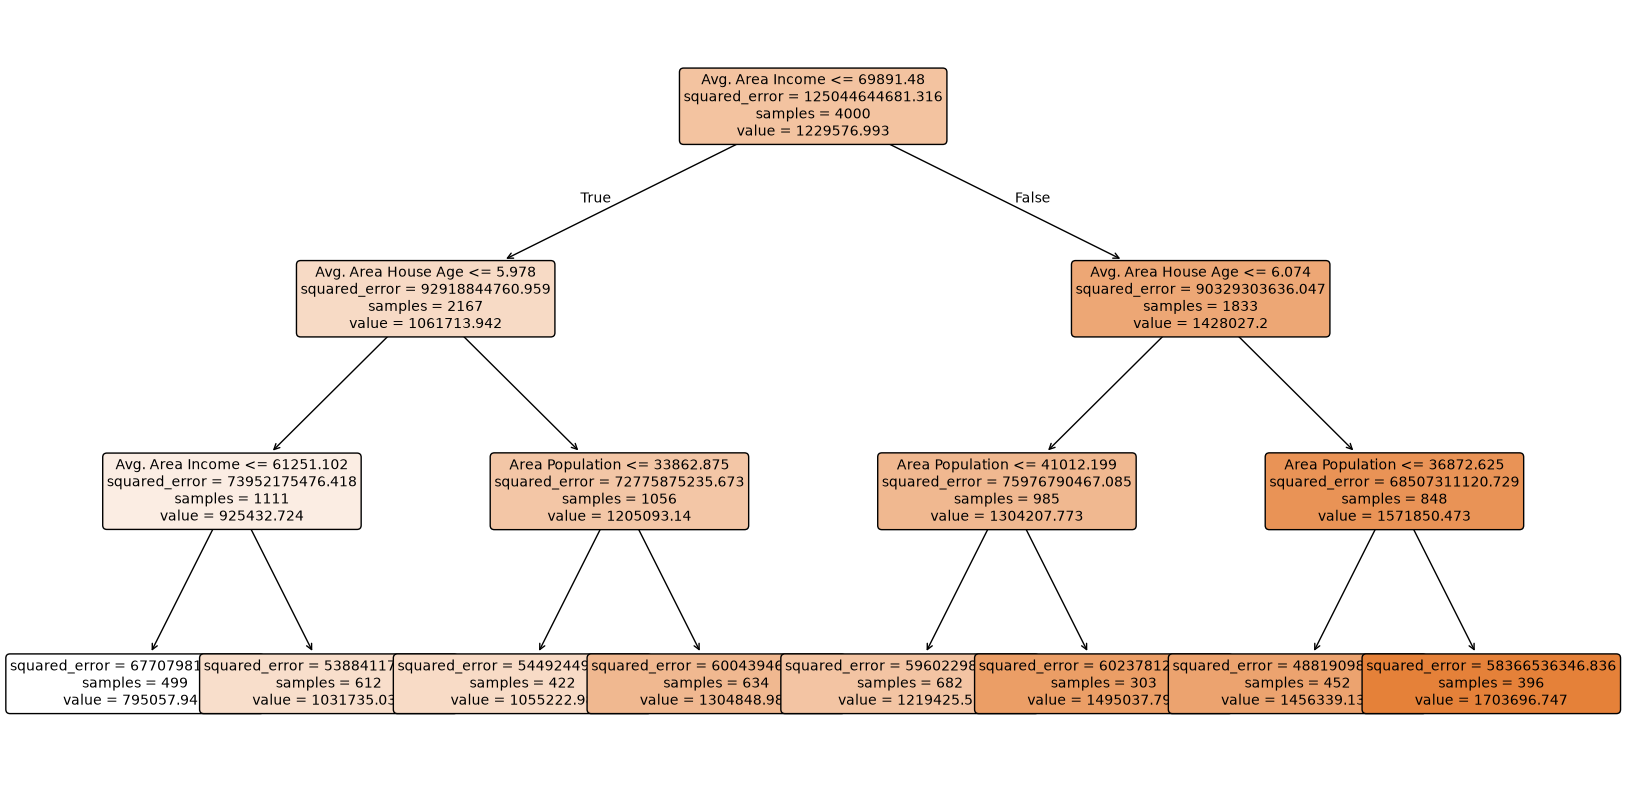

3
8


In [3]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns,
    rounded=True,
    fontsize=10
)

plt.show()
print(dt_model.get_depth())
print(dt_model.get_n_leaves())

In [4]:
joblib.dump(dt_model, "../models/decision_tree_model.joblib")

['../models/decision_tree_model.joblib']

In [5]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance

,Feature,Importance
0,Avg. Area Income,0.554093
1,Avg. Area House Age,0.279513
2,Avg. Area Number of Rooms,0.000000
3,Avg. Area Number of Bedrooms,0.000000
4,Area Population,0.166394


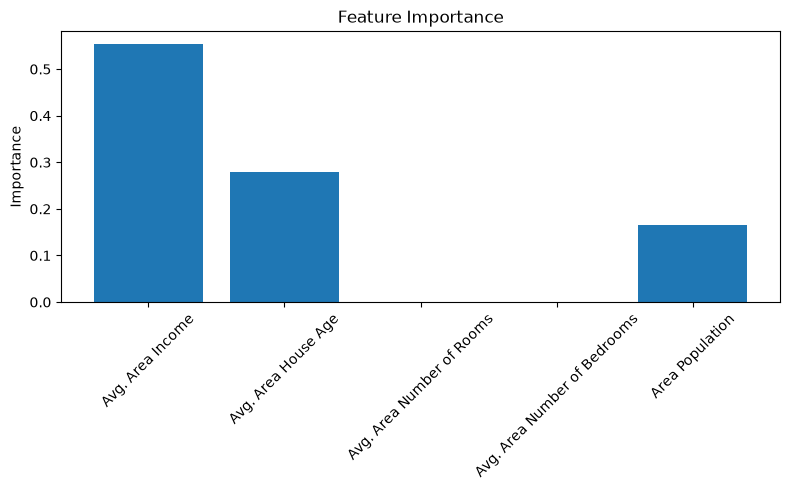

In [6]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.ylabel("Importance")

plt.tight_layout()

plt.show()

### Why Decision Tree performing so badly?
Huge drop of r2 value. This depends on max_depth. We limited it to 3, so it asked only few questions before deciding. Limit 3 is just for visualization. This is called underfitting. This tree never needed rooms and bedrroms to decide so those are 0.

In [7]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 140632.51343115998
RMSE: 178094.24189711572
R² : 0.7422016870960992


it is memorizing data -> overfitting.  
**Dataset decides winner, Linear regression is better for only this type of dataset. But Decision Tree is much more reliable in other cases.**